In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("walkrun.csv")
df.head()


,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [3]:
df.shape


(88588, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [5]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


In [6]:
df.drop(["date", "time", "username"], axis=1, inplace=True)
df.head()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [7]:
le = LabelEncoder()
df["activity"] = le.fit_transform(df["activity"])

df["activity"].value_counts()

activity
1    44365
0    44223
Name: count, dtype: int64

In [8]:
df.isnull().sum()

wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

In [9]:
X = df.drop("activity", axis=1)
y = df["activity"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(88588, 7)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (70870, 7)
X_test: (17718, 7)


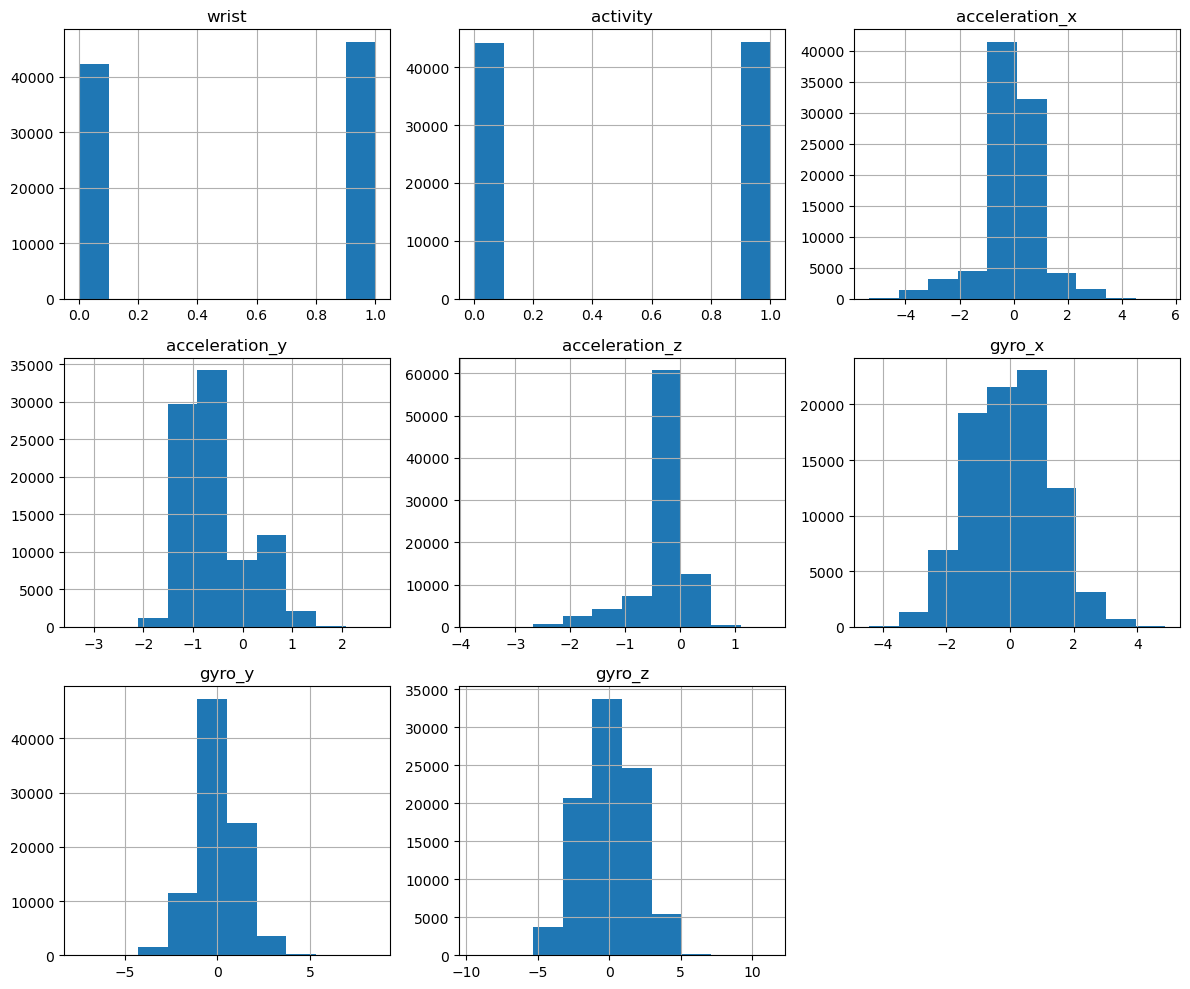

In [11]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

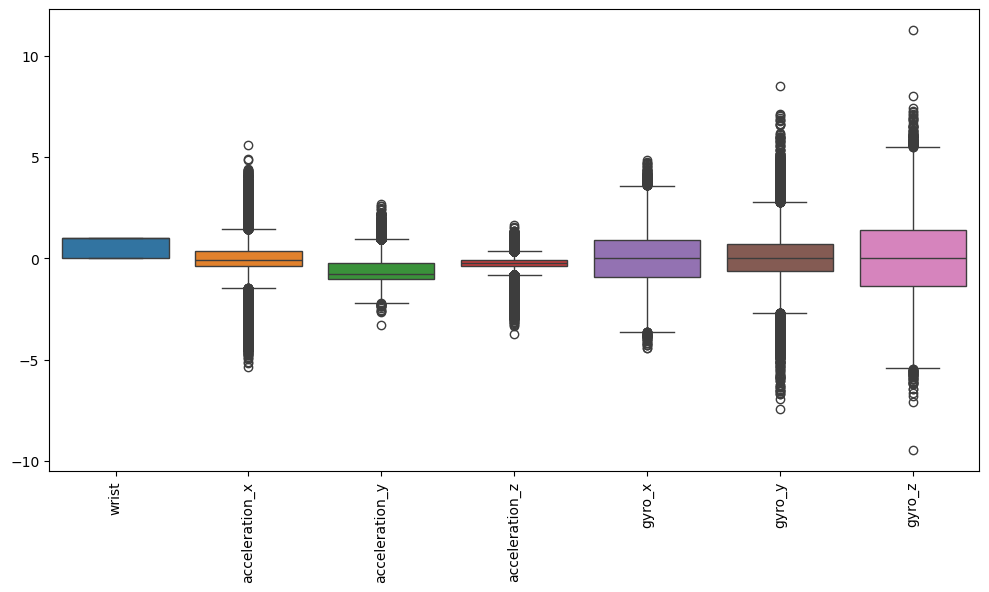

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("activity", axis=1))
plt.xticks(rotation=90)
plt.show()

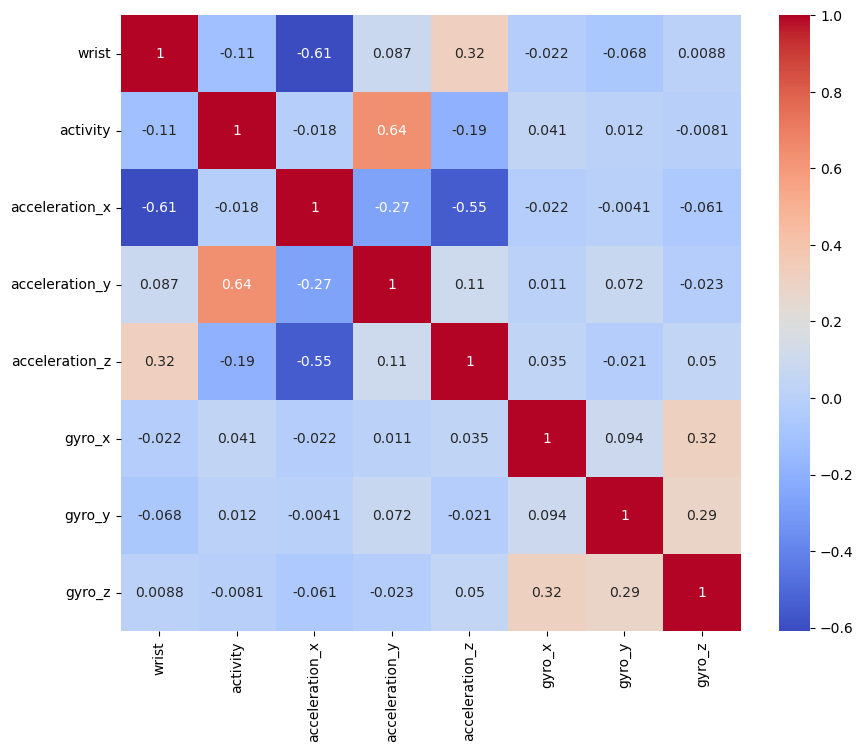

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.8634721751890733
[[8115  798]
 [1621 7184]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      8913
           1       0.90      0.82      0.86      8805

    accuracy                           0.86     17718
   macro avg       0.87      0.86      0.86     17718
weighted avg       0.87      0.86      0.86     17718


KNN
Accuracy: 0.99153403318659
[[8878   35]
 [ 115 8690]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8913
           1       1.00      0.99      0.99      8805

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718


SVM
Accuracy: 0.9912518342928096
[[8859   54]
 [ 101 8704]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8913
           1       0.99      0.99      0

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\ELCOT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

print("Neural Network training completed")

Epoch 1/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9732 - loss: 0.0805 - val_accuracy: 0.9870 - val_loss: 0.0380
Epoch 2/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9898 - loss: 0.0319 - val_accuracy: 0.9889 - val_loss: 0.0337
Epoch 3/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9911 - loss: 0.0279 - val_accuracy: 0.9904 - val_loss: 0.0274
Epoch 4/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9919 - loss: 0.0251 - val_accuracy: 0.9912 - val_loss: 0.0275
Epoch 5/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9922 - loss: 0.0237 - val_accuracy: 0.9910 - val_loss: 0.0252
Epoch 6/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9921 - loss: 0.0236 - val_accuracy: 0.9891 - val_loss: 0.0288
Epoch 7/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9922 - loss: 0.0221 - val_accuracy: 0.9914 - val_loss: 0.0237
Epoch 8/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9922 - loss: 0

In [18]:
nn_loss, nn_acc = model.evaluate(X_test, y_test)
nn_acc

554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9932 - loss: 0.0209


0.9932272434234619

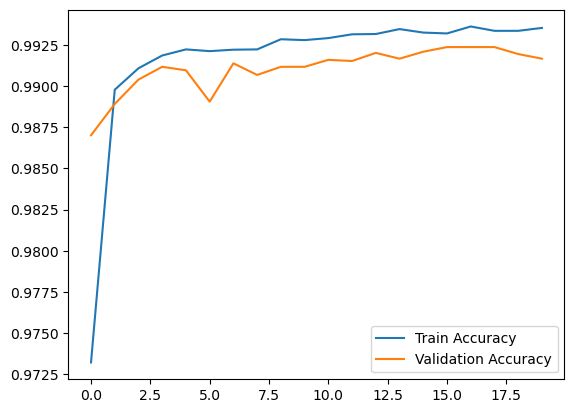

In [19]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()

In [20]:
results.append(["Neural Network", nn_acc])

comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
comparison_df

,Model,Accuracy
0,Logistic Regression,0.863472
1,KNN,0.991534
2,SVM,0.991252
3,Random Forest,0.992268
4,Neural Network,0.993227


In [29]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [21]:
import pickle

In [30]:
with open ("Random Forest.pkl","wb") as f:
           pickle.dump(model,f)
           f.close()